In [11]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_352480413_R_PULS_HS.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import dill
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     dill.load_module(session_file)
#     %matplotlib inline
#     print(f"Notebook session loaded from  {session_file}")

# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_352480413_R_PULS_HS.ipynb.pkl


In [2]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

<IPython.core.display.Javascript object>

# TIC 352480413 Analysis (R+V1093HER)

- Revising existing VSX entry (type, period, epoch)
  - https://vsx.aavso.org/index.php?view=detail.top&oid=225945 


## TESS Data

In [3]:
tic = 352480413

sr = lk.search_lightcurve(f"TIC{tic}", )  # author="SPOC", cadence="short"
sr_unfiltered = sr  # keep a copy
sr = lke.filter_by_priority(sr, author_priority = ["SPOC", "TESS-SPOC", "QLP"])
sr = sr[sr.author == "SPOC"]  # for uniformity, only 1 sector (94) has no SPOC data
sr = lke._sort_chronologically(sr)

astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

lcc_tess = sr.download_all()
lcc_tess

#,mission,year,author,exptime,target_name,distance,proposal_id
,,,,s,,arcsec,
0,TESS Sector 13,2019,SPOC,120,352480413,0.0,G011177
1,TESS Sector 27,2020,SPOC,120,352480413,0.0,G03221
2,TESS Sector 101,2026,SPOC,120,352480413,0.0,N/A
3,TESS Sector 102,2026,SPOC,120,352480413,0.0,N/A


LightCurveCollection of 4 objects:
    0: <TessLightCurve LABEL="TIC 352480413" SECTOR=13 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 352480413" SECTOR=27 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 352480413" SECTOR=101 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 352480413" SECTOR=102 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>

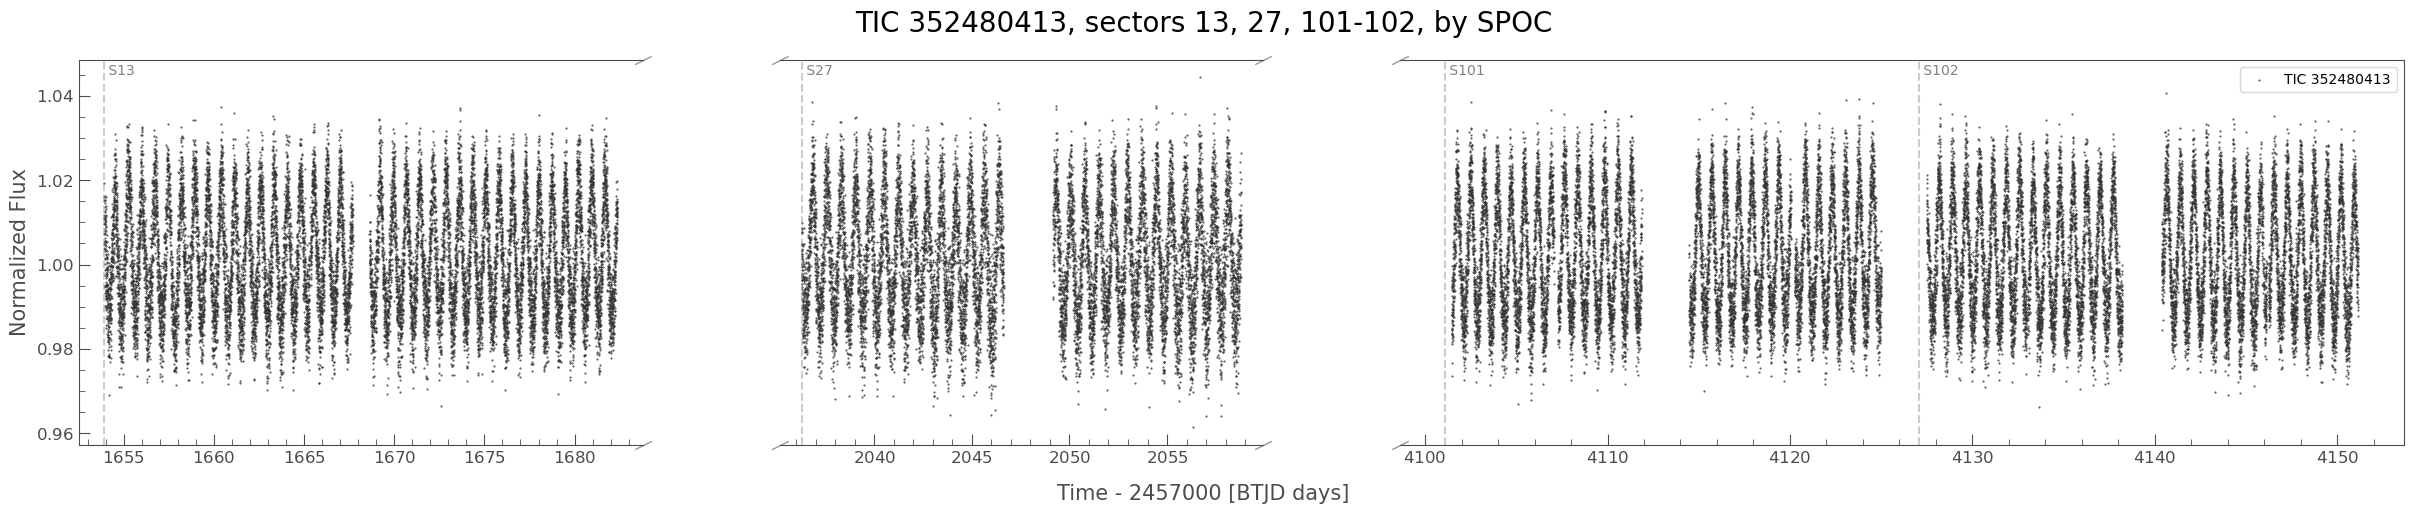

In [53]:
_lc = lke.stitch(lcc_tess, corrector_func=lambda lc: lke.select_flux(lc, ["flux"]).normalize(), ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=1, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
# [ax.set_ylim(0.95, 1.05) for ax in axs];


In [55]:
tplt.plot_transit_interactive(_lc, figsize=(20, 8));

Output(layout=Layout(border_bottom='1px solid lightgray', border_left='1px solid lightgray', border_right='1px…

Output(layout=Layout(padding='1em'))

## Gaia DR3 info (coordinate, etc.)

In [5]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=15, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)


In [6]:
primary_name = " JL 82"  # use existing VSX name # f"TIC {tic}"
primary_name

' JL 82'

## Combining all data


### TESS Data (in mag, HJD)

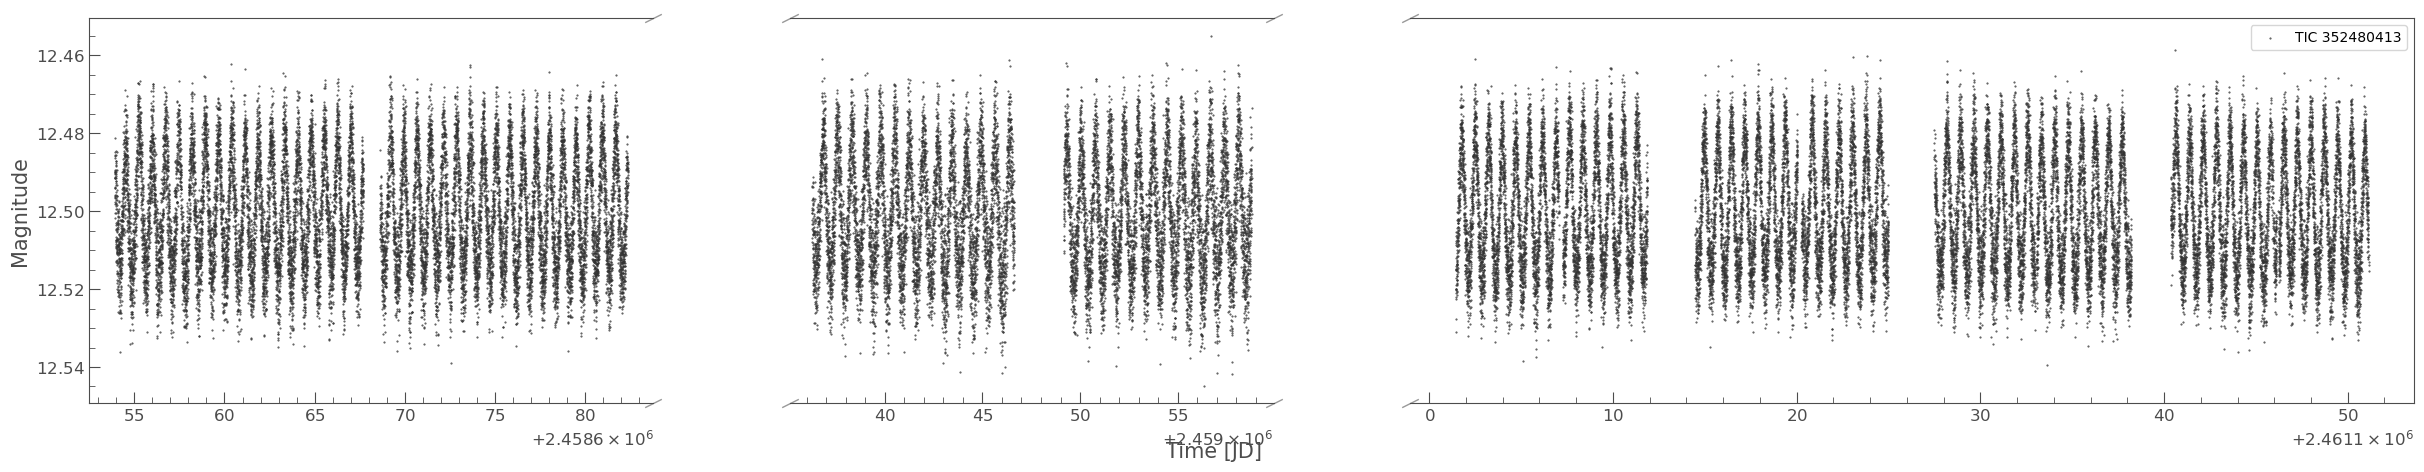

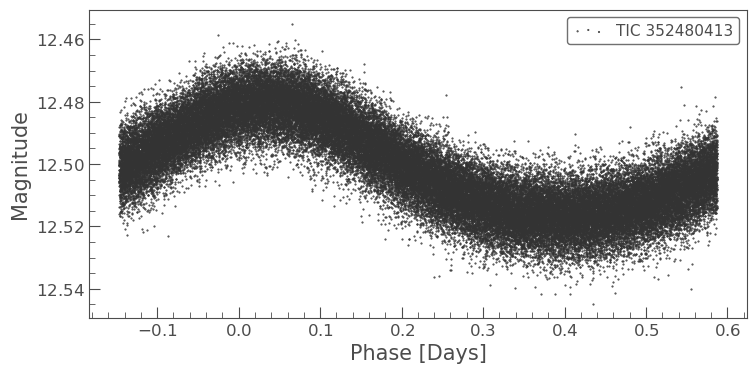

In [7]:
_lc = lke.stitch(lcc_tess)

_lc = lke.to_flux_in_mag_by_normalization(_lc)
_lc = lke.convert_lc_time_to_hjd_utc(_lc, target_coord, cache_dir=lk_download_dir)

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=1, alpha=0.9);

# rough folded LC to visualize the results
_lc_f = _lc.fold(epoch_time=Time(2458654.5, format="jd", scale="utc"), period=0.733799 , wrap_phase=0.733799 * 0.8)
tplt.scatter(_lc_f, s=1);

lc_tess = _lc

### Gaia DR3 data

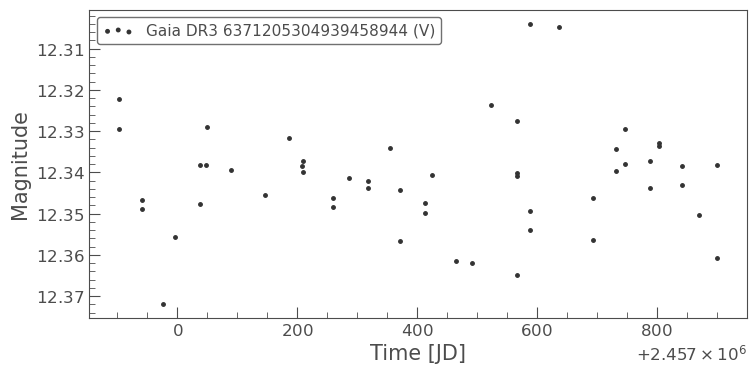

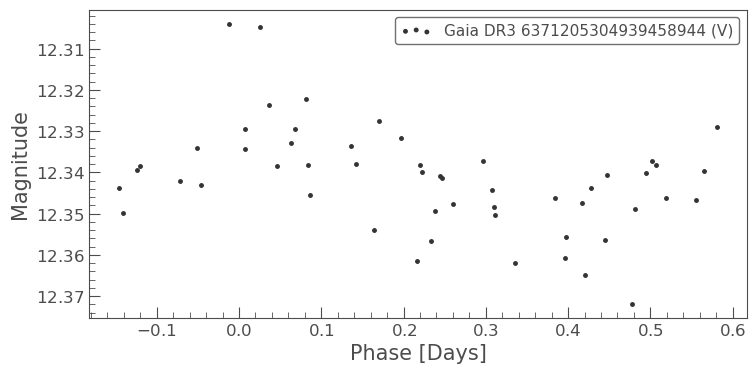

In [8]:
from io import StringIO
from astropy.table import Table

# plot: https://cdsarc.cds.unistra.fr//vizier/vizgraph.gml?-s=I/355&-i=.graph_sql_epphot&Pos=324.00566066895-72.80763970392&Source=6371205304939458944
# data: https://cdsarc.cds.unistra.fr/viz-bin/vizgraph?-s=I%2F355&-i=.graph_sql_epphot&Pos=324.00566066895-72.80763970392&Source=6371205304939458944&--output=tsv
# only the Gmag portion
# VizieR  - Graph output I/355 light curves of Gaia DR3 5831536483793346816
# Resource:G
# JD-2455197.5
# G [mag]
_tab = Table.read(
    """\
time 	 mag	
1705.430291 	12.329448	
1705.504323 	12.322173	
1744.061029 	12.348794	
1744.135059 	12.346741	
1779.279656 	12.371818	
1798.278543 	12.355652	
1839.791372 	12.338295	
1839.967530 	12.347667	
1851.221660 	12.338130	
1851.295667 	12.329107	
1892.417748 	12.339415	
1948.396499 	12.345531	
1988.131931 	12.331785	
2011.462994 	12.338523	
2011.639104 	12.340000	
2011.713161 	12.337195	
2061.625129 	12.348325	
2061.699106 	12.346257	
2089.446185 	12.341343	
2120.607138 	12.343733	
2120.681169 	12.342110	
2157.392351 	12.334208	
2173.819722 	12.356749	
2173.893728 	12.344388	
2215.830139 	12.347507	
2216.006299 	12.349893	
2228.334320 	12.340644	
2268.462490 	12.361403	
2293.531230 	12.362085	
2325.519157 	12.323750	
2369.681000 	12.327587	
2369.755009 	12.340808	
2369.931185 	12.364937	
2370.005179 	12.340158	
2391.513100 	12.303932	
2391.689228 	12.354089	
2391.763264 	12.349388	
2439.247415 	12.304872	
2496.902477 	12.356333	
2496.976496 	12.346153	
2535.180822 	12.339612	
2535.356972 	12.334231	
2549.359761 	12.329370	
2549.433790 	12.337921	
2591.545753 	12.343905	
2591.619733 	12.337298	
2605.856702 	12.332870	
2605.930711 	12.333680	
2644.565529 	12.338421	
2644.639540 	12.343010	
2672.881047 	12.350431	
2702.875527 	12.338171	
2703.051692 	12.360831""".splitlines()
,
    format="ascii.csv",
    delimiter="\t",
)

_lc = lk.LightCurve(time=Time(_tab["time"] + 2455197.5, format="jd", scale="tdb"), flux=_tab["mag"] * u.mag)

_lc["flux_err"] = 0.002820 * u.mag  # use mean Gmag error for now -- https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a36bf5d1c7c2a&-out.add=.&-source=I/355/gaiadr3&-c=324.00566066895%20-72.80763970392,eq=ICRS,rs=2&-out.orig=o

_lc["gmag"] = _lc["flux"]
_lc["gmag_err"] = _lc["flux_err"]

# Gaia DR3 G to V transform
# SO: the G-to-V transform can be done via a linear offset of the G to V based on the mean G mag and mean B-R
# given the target is an EW without color changes throughout the cycle

gdr3_g_to_v_offset = np.round(12.399 - 12.342) * u.mag  # Vmag - Gmag
_lc["flux"] += gdr3_g_to_v_offset


_lc.meta["TARGET"] = "Gaia DR3 6371205304939458944"
_lc.meta["LABEL"] = "Gaia DR3 6371205304939458944 (V)"
tplt.scatter(_lc, s=25);


lc_gdr3 = _lc 

lc_gdr3 = lke.convert_lc_time_to_hjd_utc(lc_gdr3, target_coord=target_coord, cache_dir=lk_download_dir, cache_key="gdr3_6371205304939458944")

# rough folded LC to visualize the results
_lc_f = lc_gdr3.fold(epoch_time=Time(2458654.5, format="jd", scale="utc"), period=0.733799 , wrap_phase=0.733799 * 0.8)
tplt.scatter(_lc_f, s=25);


### Do Actual combining

TESS # data points: 70646
Gaia DR3 V # data points: 53


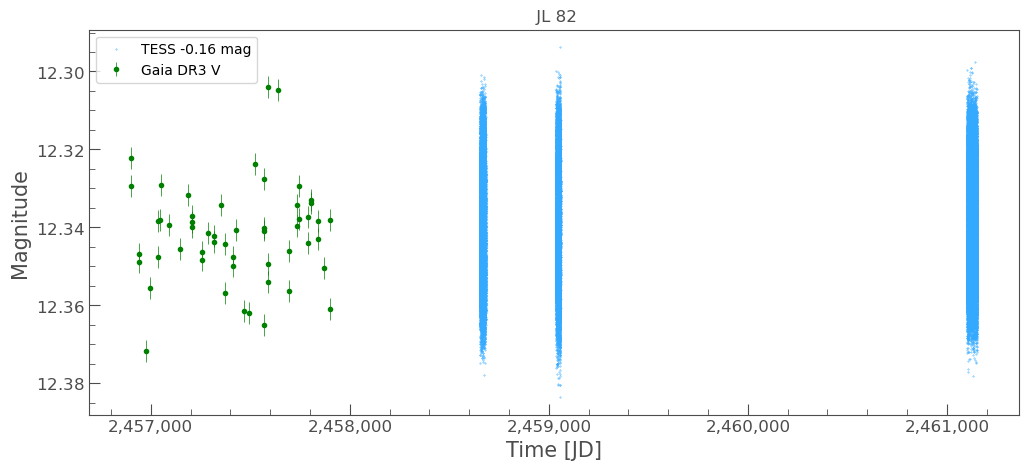

In [9]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
# reload(lkem)

lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"TESS": lc_tess,
     "Gaia DR3 V": lc_gdr3, 
    }, 
    shift_to="Gaia DR3 V",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

plot_options = lkem.get_default_plot_multi_bands_options_copy()
# for TESS plot (index 0) move it to the front
# plot_options[0][1]["zorder"] = 3  # default 2

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name, plot_options=plot_options);
# ax.set_ylim(15.2, 14.0);

## Initial epoch / period / duration


Adopted period / epoch / duration_hr:  0.733799 2458654.897


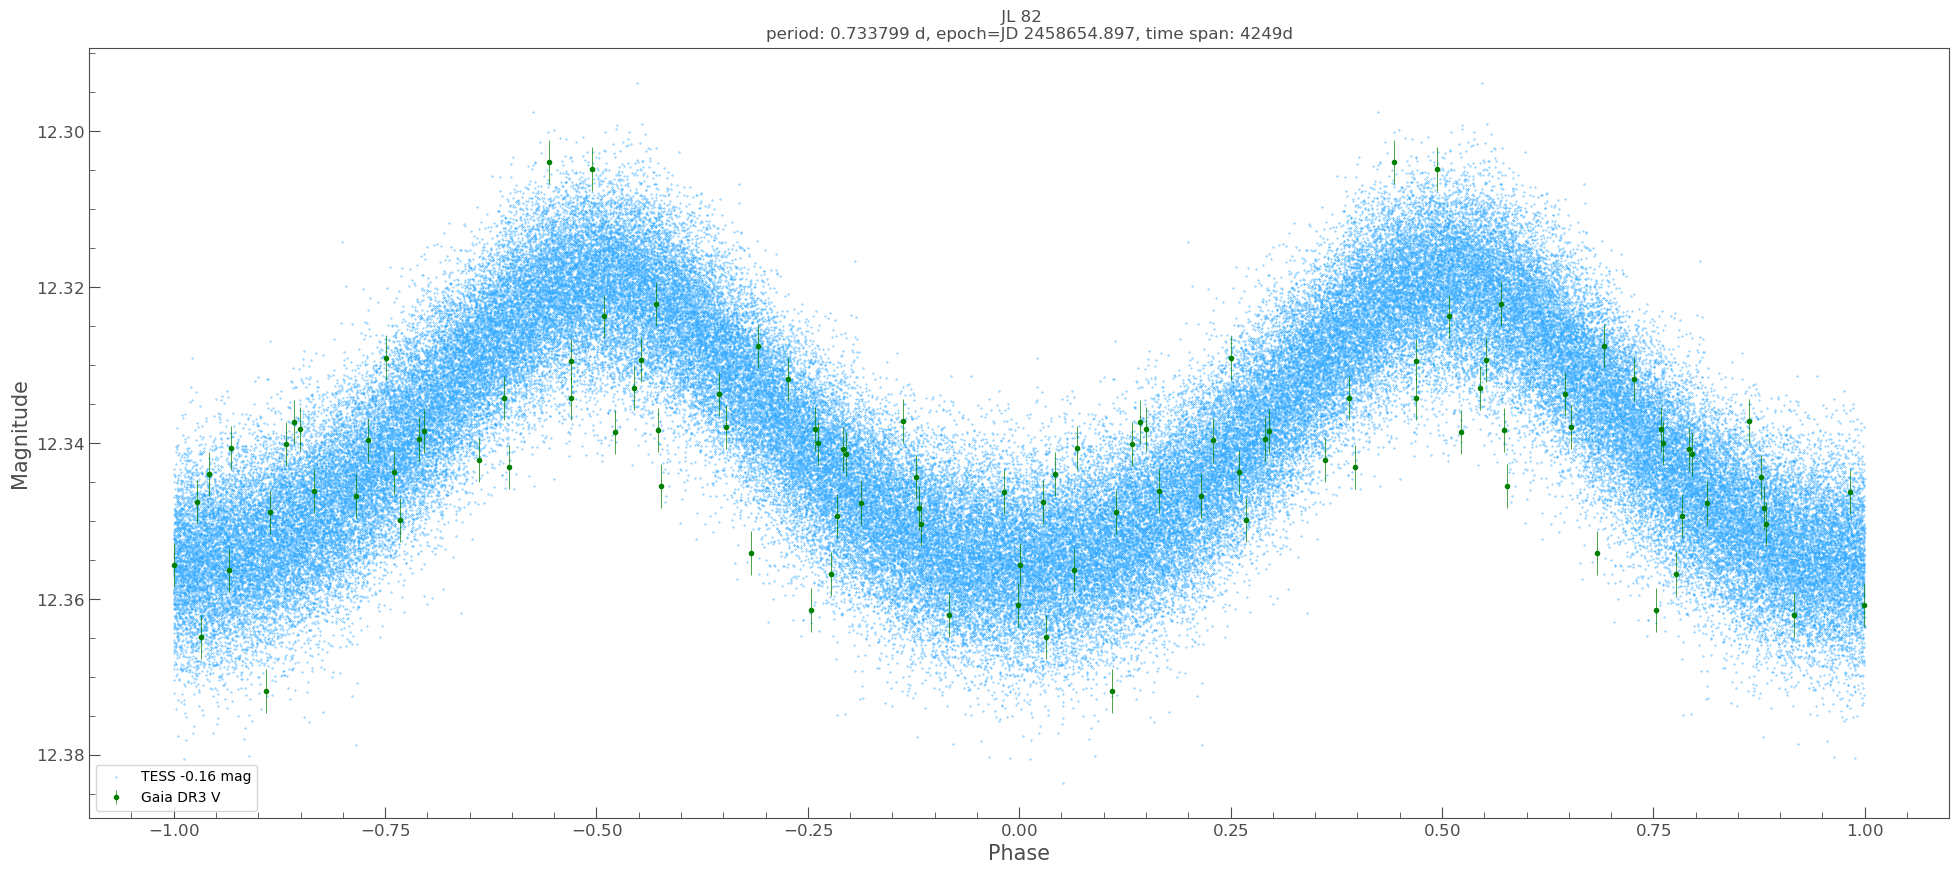

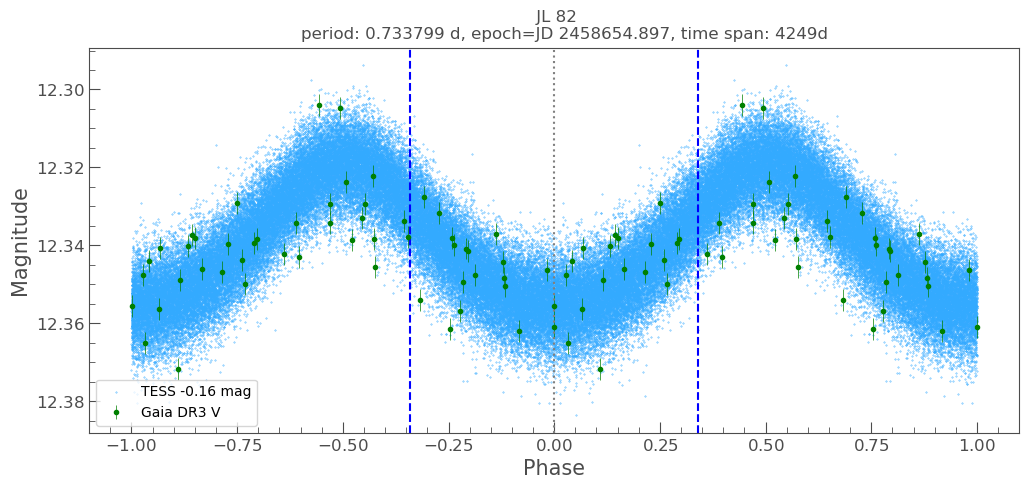

In [33]:
# reload(lkem)

# epoch / period : rought fit from TESS data
period_trial = 0.733799
epoch_time_hjd_trial = 2458654.897
# epoch_time_min_ii_hjd_trial = round(epoch_time_hjd_trial + period_trial * 0.5, 2)  # at phase 0.5
# epoch_phase_min_ii_trial   = round(abs(epoch_time_min_ii_hjd_trial   - float(epoch_time_hjd_trial)  ) / period_trial   % 1, 1)

duration_hr_min_i_trial = 12  # not real eclipse duration, but just a way to mark the eclipses approximately
# duration_hr_min_ii_trial = 4.5



print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial)  # , duration_hr_min_i_trial, duration_hr_min_ii_trial

# --- Plot them to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - larger dots to be more visible, move TESS to front
plot_options_zoom = plot_options


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_xlim(-0.22, 0.22);  # to see primary in details
ylim = (None, None)
ax.set_ylim(*ylim);


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_trial,
#     epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
#     duration_midpoint_phase=epoch_phase_min_ii_trial,
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(epoch_phase_min_ii_trial, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_trial - 0.22, epoch_phase_min_ii_trial + 0.22);  # to secondary in details
# ax.set_ylim(*ylim);


## Period refinement with MCMC


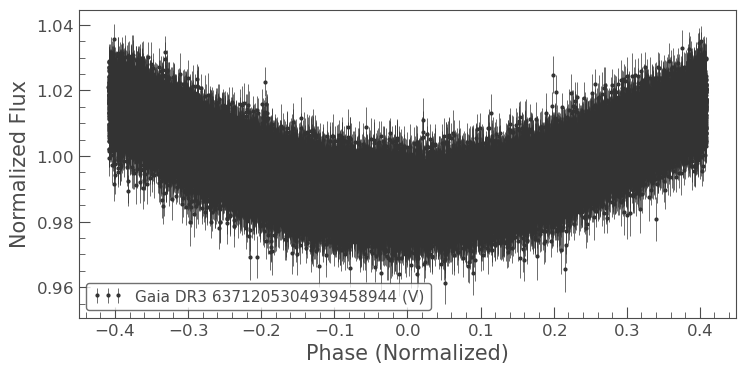

In [73]:
_lc = lke.stitch_lc_dict(lc_combined_dict, normalize=True).remove_nans() 

lc_f_min_i = _lc.fold(epoch_time=epoch_time_hjd_trial, period=period_trial, normalize_phase=True)
lc_f_min_i = lc_f_min_i.truncate((0 - duration_hr_min_i_trial / 24 * 0.6) / period_trial, (0 + duration_hr_min_i_trial /24 * 0.6) / period_trial)
lc_f_min_i = lc_f_min_i.truncate(None, 1.5, column="flux")  # crude outlier removal
# ax1 = tplt.scatter(lc_f_min_i, c=lc_f_min_i.time_original.value, s=25);
ax1 = tplt.errorbar(lc_f_min_i);  # use errobar as a sanity, as MCMC requires non-nan error

In [41]:
from types import SimpleNamespace

import sys
if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
    sys.path.append("../eb_with_diff_sb_period/etv/")

import etv_functions_with_period as etvp
import etv_functions
# reload(etvp)

lc_f = lc_f_min_i

# # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # t0 in normalixed phase
start_vals = [1.023, -0.038, 0, 0.28, 1.05]


# convert lc to the form needed by fit etv_functions
lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

Output(layout=Layout(padding='1em 0px'), outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Fig…

Output(layout=Layout(padding='1em'), outputs=({'name': 'stdout', 'text': '[1.023, -0.038, 0, 0.28, 1.05]\n\n',…

100%|██████████████████████████████████████████████████████████| 1600/1600 [36:52<00:00,  1.38s/it]
The chain is shorter than 20 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/20 = 80;
tau: [ 46.39329883  41.98781075  83.46636329  85.1330655  158.82780951
  30.75055212]


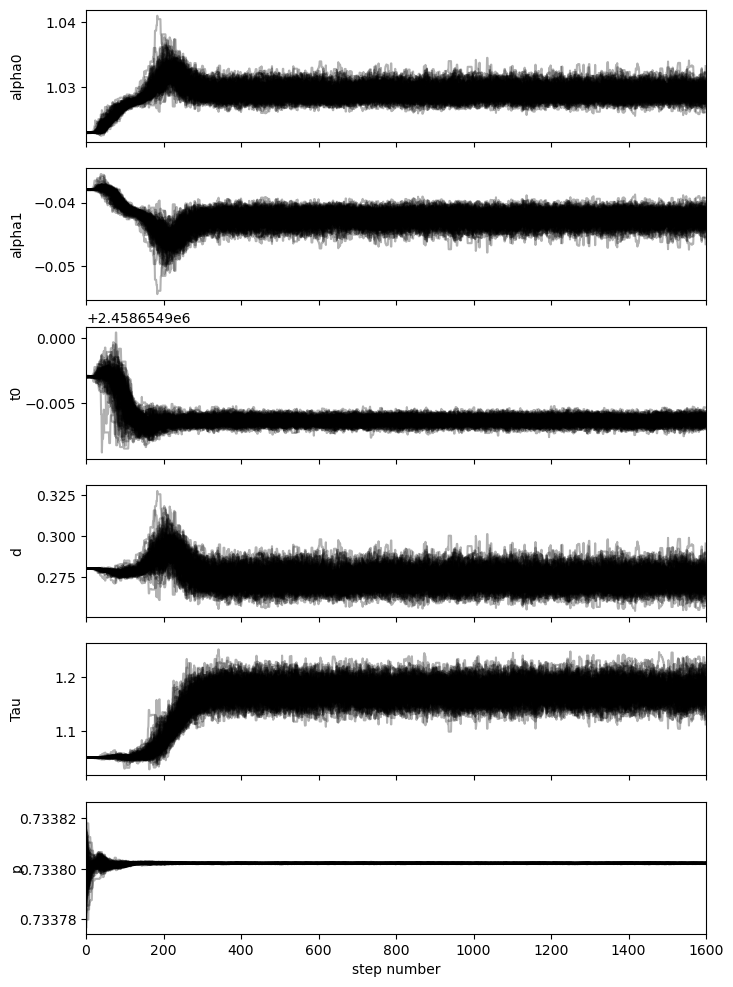

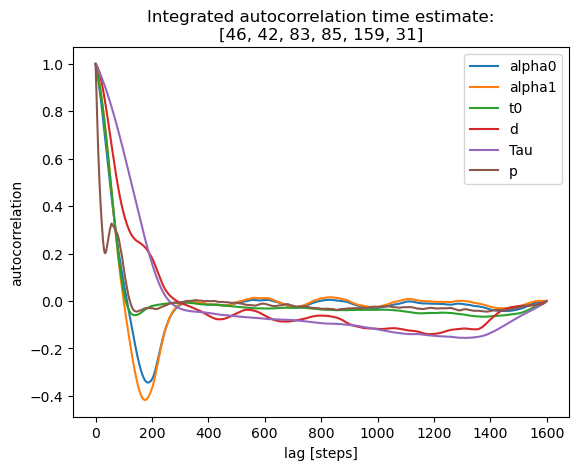

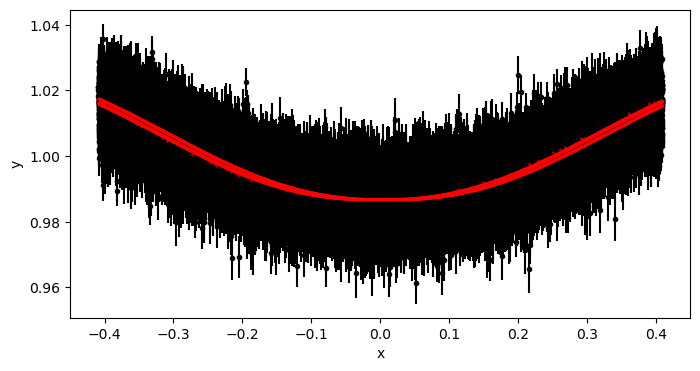

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = 1.0291675972515129, -0.04237791135257983, 2458654.8936323673, 0.27346258109524724, 1.174910377561862, 0.7338022613848629
std_t0: 0.00029485349729333675
std_p: 1.210187815338912e-07


In [47]:
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
    lc_f_data, 
    [1.023, -0.038, epoch_time_hjd_trial, 0.28, 1.05, period_trial],
    # nruns=20, discard=1,
    nruns=1600, discard=600,
    # nruns=4000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2,
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
print("std_t0:", fit_params_p_stats["std_t0"])
print("std_p:", fit_params_p_stats["std_p"])


## Final period / epoch / duration

Adopted period / epoch / duration_hr:  0.733802 2458655.26


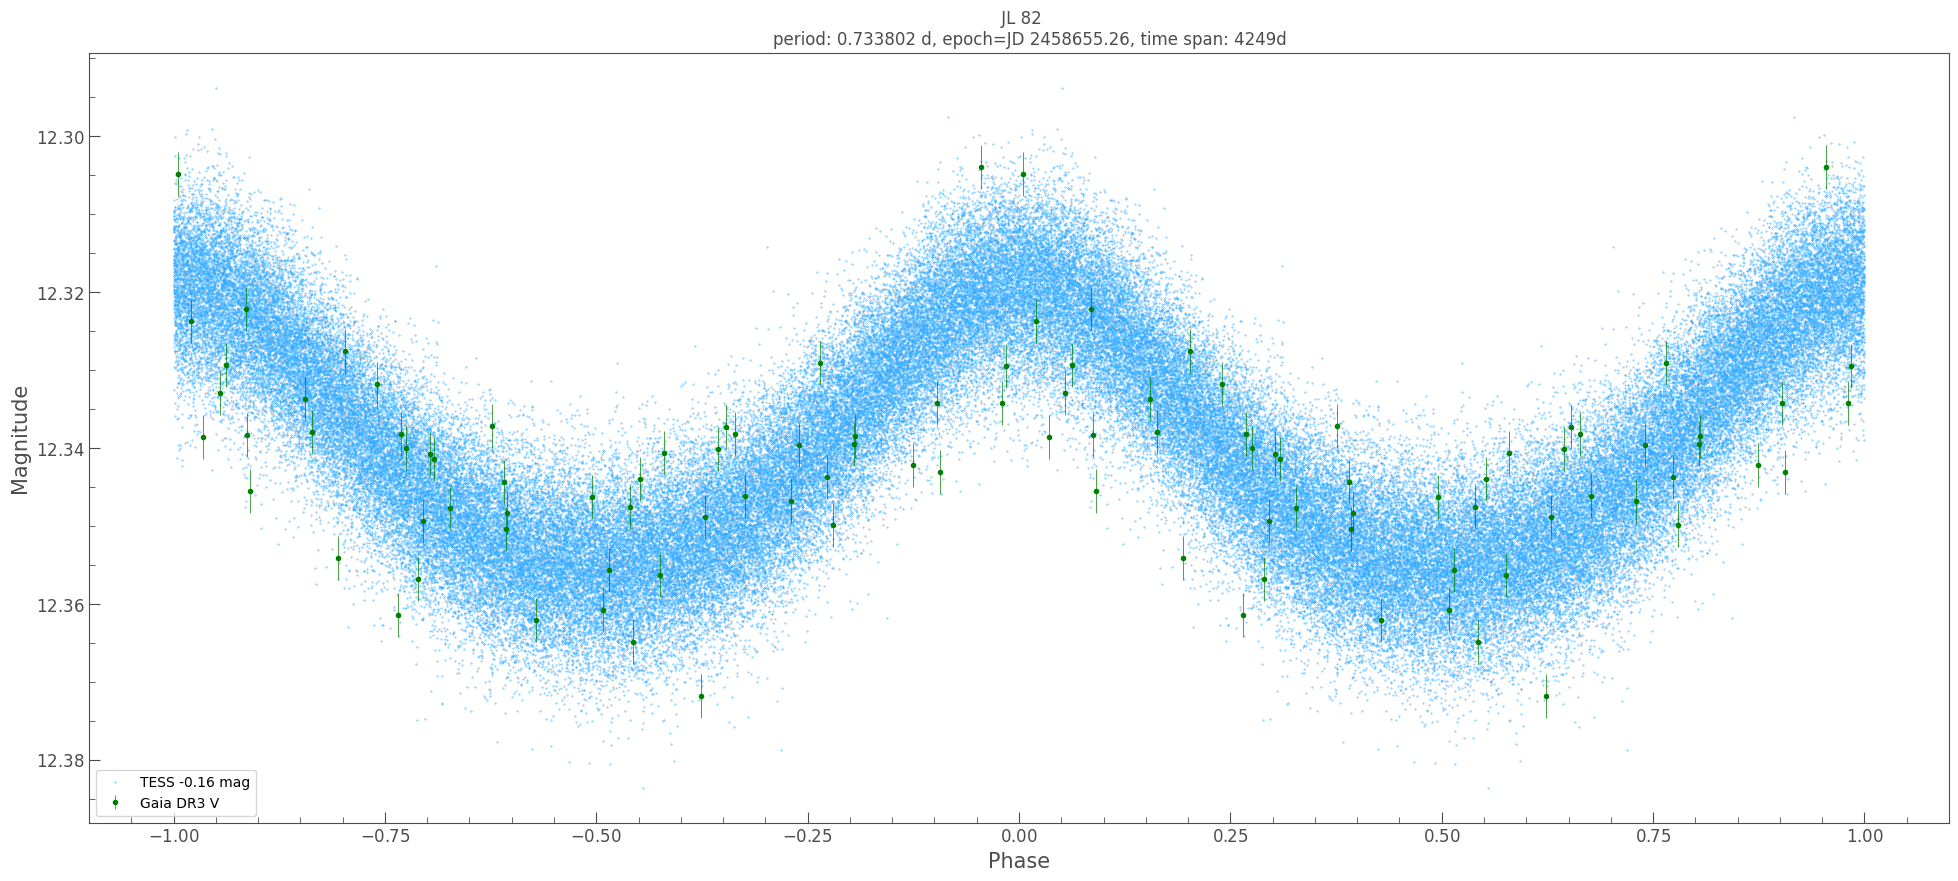

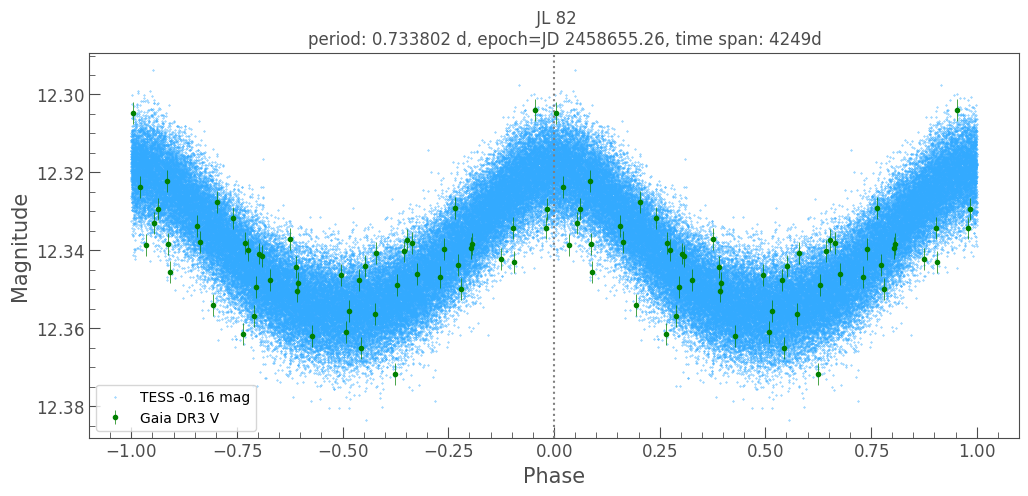

In [8]:
# reload(lkem)
# from decimal import Decimal

# MCMC
# epoch:   2458654.8936323673 +/- 0.0003
# period:  0.7338022613848629 +/-   1.20595004376526e-07
#
period_final = 0.733802      # from MCMC value , errorbar is 1.2e-07, so keep the 6th digit
epoch_time_hjd_final = np.round(2458654.89 + 0.733802 * 0.5, 2)  # SO: for reflection plot, epoch is max  # from MCMC value, with errorbar is 0.0003, it's between. 2458654.893 and 2458654.894
# duration_hr_min_i_final = duration_hr_min_i_trial  # duration_hr used for plotting aide only , skip it

# epoch_time_min_ii_hjd_final = round(float(epoch_time_hjd_final) + period_final * 0.5, 2)
# epoch_phase_min_ii_final   = abs(epoch_time_min_ii_hjd_final   - float(epoch_time_hjd_final)  ) / period_final   % 1
# if epoch_phase_min_ii_final   > 0.5:
#     epoch_phase_min_ii_final   = epoch_phase_min_ii_final   - 1
# epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 1)  # circular, also looks fine in folded LC below
# duration_hr_min_ii_final = duration_hr_min_ii_trial


print("Adopted period / epoch / duration_hr: ", period_final, epoch_time_hjd_final)  # , epoch_phase_min_ii_final , duration_hr_min_i_final, duration_hr_min_ii_final)

# --- plot to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = plot_options


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    # lke.get_lc_dict_subset(lc_combined_dict, "TESS"),
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_xlim(-0.2, 0.2);  # to see primary in details
ylim = (None, None)
ax.set_ylim(*ylim);

# # Min I super zoom
# ax = tplt.scatter(lc_f_res["TESS"].truncate(-0.001, 0.001), c="#3AF");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_title(f"Min I: {epoch_time_hjd_final}");

# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_final  ,  # for plotting only
#     duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final -0.2, epoch_phase_min_ii_final + 0.2);  # to see secondary in details
# ax.set_ylim(*ylim);


In [ ]:
# demonstrate the precision difference in duration percentage 
# - 0 or 1 digit for percetnarge would be appropriate
# for _precision in [0, 1, 2, 3, 4]: 
#     _dur_pct = round(100 * duration_hr_min_i_final / 24 / period_final, _precision)
#     _dur_hr = _dur_pct /100 * 24 * period_final
#     # zoom plot Min I
#     # - make TESS more visible:  larger dots
#     plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
#     plot_options_zoom[0][1]["s"] = 25
#     ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#         lc_combined_dict,
#         period=period_final,
#         epoch=Time(epoch_time_hjd_final  , format="jd", scale="utc"),
#         phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#         target_name=primary_name,
#         duration_hr=_dur_hr,  # for plotting only
#         figsize=(12, 5),
#         plot_options=plot_options_zoom,
#         # mag_shift_precision=2,  #
#     );
#     ax.set_ylim(*ylim);
#     ax.legend(loc="lower left");
#     ax.axvline(0, c="gray", linestyle="dotted");
#     ax.set_xlim(-0.075, 0.075);  # to see primary in details
#     ax.set_title(ax.get_title() + f",  duration: {_dur_pct}%, {_dur_hr:.1f} h");
#     # print(_dur_pct, _dur_hr, duration_hr_min_i_final) 

## Pulsation Variability

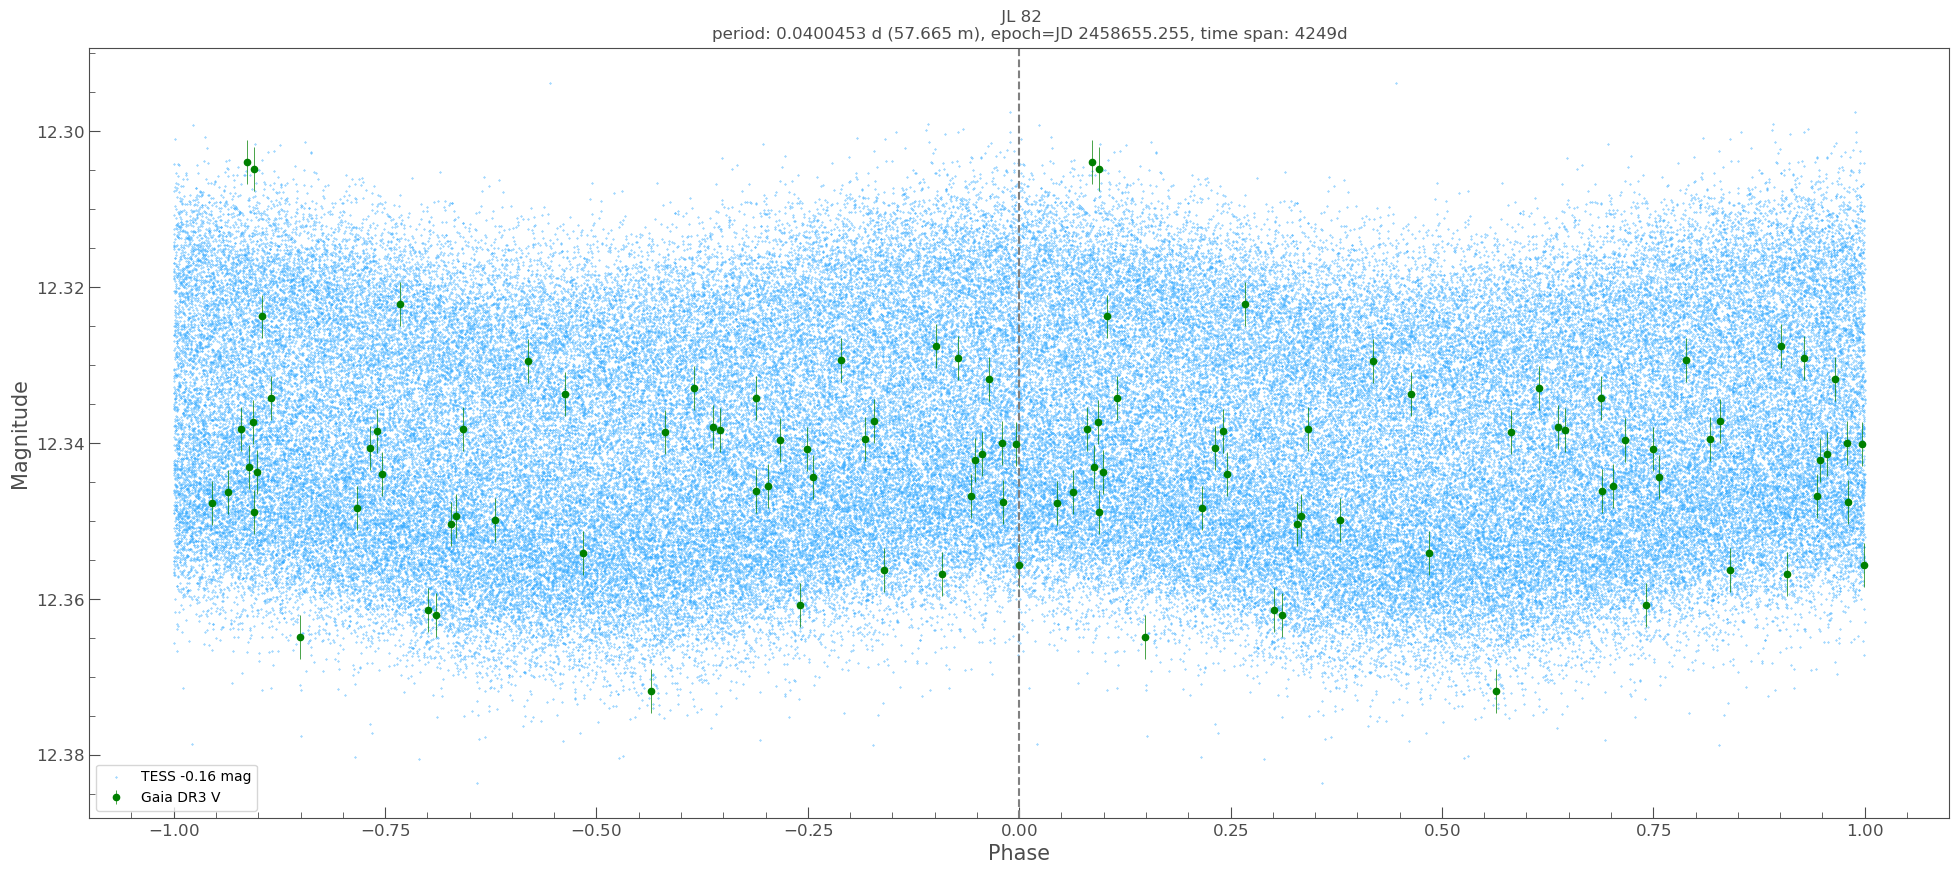

In [95]:
puls_period_final = 0.0400453  # rounded from 0.04004528169270583, from LS Periodogram freq: 24.97173094382672 1/d, fwhm 0.00035053 1 /d, or period in [0.04004528 0.04004556 0.040045  ] d
puls_epoch_final = 2458655.255  # by inspectoion

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=puls_period_final,
    epoch=Time(puls_epoch_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ax.axvline(0, linestyle="--", c="gray");

## Determine Range (zero-shifted TESS as V)

- Treat zero-shfited TESS data as if it is V, given that Gaia DR3 V and zero-shfited TESS data track pretty well.
- So treat zero-shifted TESS data as extrapolated V band data

Max mag # num data points: 31
Min mag # num data points: 29
12.32 12.36


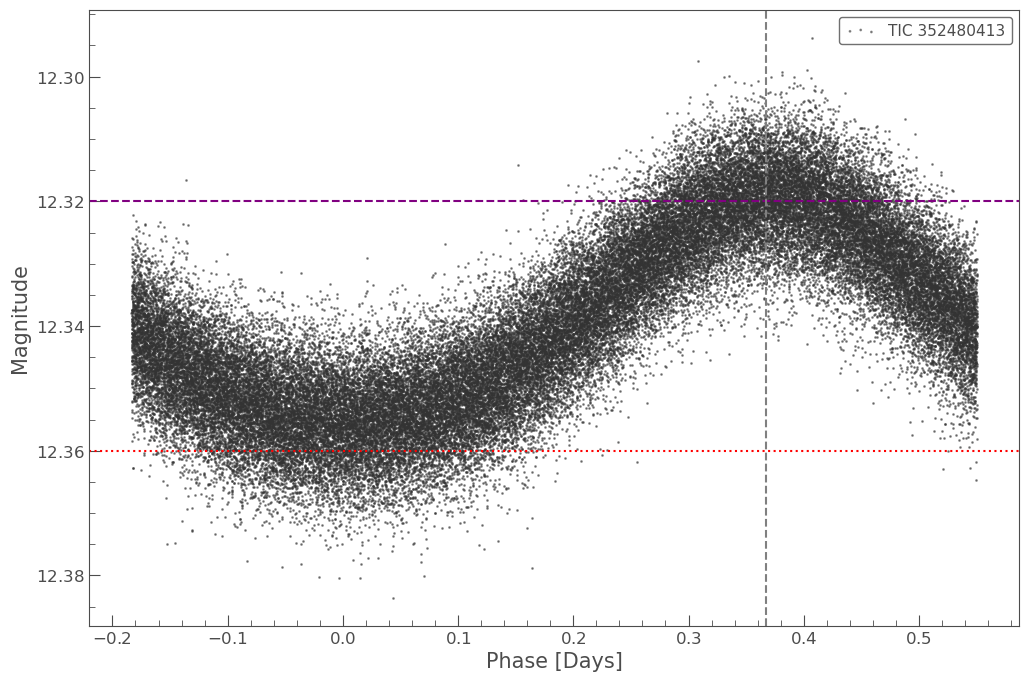

In [60]:
# %matplotlib widget
%matplotlib inline

# From Gaia DR3 data, the data does not seem to have much outliers, and seem to reach min/max, so I took the min/max as-is
lc = lc_combined_dict["TESS"]

# gdeduce from the median instead
# max_flux_vmag = np.round(lc.flux.min().value, 2)
# min_flux_vmag = np.round(lc.flux.max().value, 2)


# # median_flux_vmag = np.nanmedian(lc.flux.value)

# no max neded, medain is basically max
lc_zoom_max = lc.fold(epoch_time=epoch_time_hjd_final + period_final * 0.5, period=period_final).truncate(0 - 0.25 /24/60, 0 + 0.25 /24/ 60)  
print("Max mag # num data points:", len(lc_zoom_max))
max_flux_vmag = np.round(float(np.nanmedian(lc_zoom_max.flux.value)), 2)

lc_zoom_min = lc.fold(epoch_time=epoch_time_hjd_final + 0, period=period_final).truncate(0 - 0.25 /24/60, 0 + 0.25 /24/ 60)
print("Min mag # num data points:", len(lc_zoom_min))
min_flux_vmag = np.round(float(np.nanmedian(lc_zoom_min.flux.value)), 2)

lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final, wrap_phase=period_final*0.75)
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
ax.axhline(max_flux_vmag, c="purple", linestyle="--", label="Max")
ax.axhline(min_flux_vmag, c="red", linestyle="dotted", label="Min")
ax.axvline(period_final * 0.5, linestyle="--", c="gray", label="Phase max");  # double check to ensure min phase is accurate
print(max_flux_vmag, min_flux_vmag)

# lc_zoom_min_ii = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final).truncate(0 - 3 /24/60, 0 + 3 /24/ 60)
# print("Min II mag # num data points:", len(lc_zoom_min_ii))
# min_ii_flux_vmag = np.nanmedian(lc_zoom_min_ii.flux.value)


# lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final * 2)  # 2x period plot
# ax = tplt.lk_ax(figsize=(12, 8))
# ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# # ax.axhline(max_flux_vmag, c="purple", linestyle="--", label="Max")
# ax.axhline(median_flux_vmag, c="blue", linestyle="dotted", label="Median")
# ax.axhline(min_flux_vmag, c="red", linestyle="dotted", label="Min I")
# ax.axhline(min_ii_flux_vmag, c="orange", linestyle="dotted", label="Min II")
# ax.legend(loc="lower right");
# # ax.set_xlim(-0.5, 0.5); 
# ax.set_ylim(*ylim);


# ax = tplt.errorbar(lc_zoom_min, marker="o");
# ax.axhline(min_flux_vmag, c="red", linestyle="dotted", label="Min I")
# # ax.set_ylim(*ylim);
# ax.legend();

# ax = tplt.errorbar(lc_zoom_min_ii, marker="o");
# ax.axhline(min_ii_flux_vmag, c="red", linestyle="dotted", label="Min II")
# ax.legend(loc="lower right");

# print([f"{v:.4f}" for v in [median_flux_vmag, min_flux_vmag, min_ii_flux_vmag]])  # 


# # # TESS only data, to report mean V mag and ampitude in TESS
# # mean_flux_v_vmag = np.round(rs_all_cols["Vmag"][0], 2)  # V converted from Gaia DR3 - here I use other sources

# # amp_flux_vmag = np.round(np.abs(float(min_flux_vmag - max_flux_vmag)) , 3)  # in TESS band, probably don't have 4 digit precison

# amp_min_i_flux_vmag = np.round(np.abs(float(min_flux_vmag - median_flux_vmag)) , 3)  

# amp_min_ii_flux_vmag = np.round(np.abs(float(min_ii_flux_vmag - median_flux_vmag)) , 3)  

# (amp_min_i_flux_vmag, amp_min_ii_flux_vmag)  # amp_flux_vmag,

## Plots for VSX

In [69]:
# custom default plot ptions
plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[1][1]['markersize'] = 9  # make Gaia DR3 V data dots larger

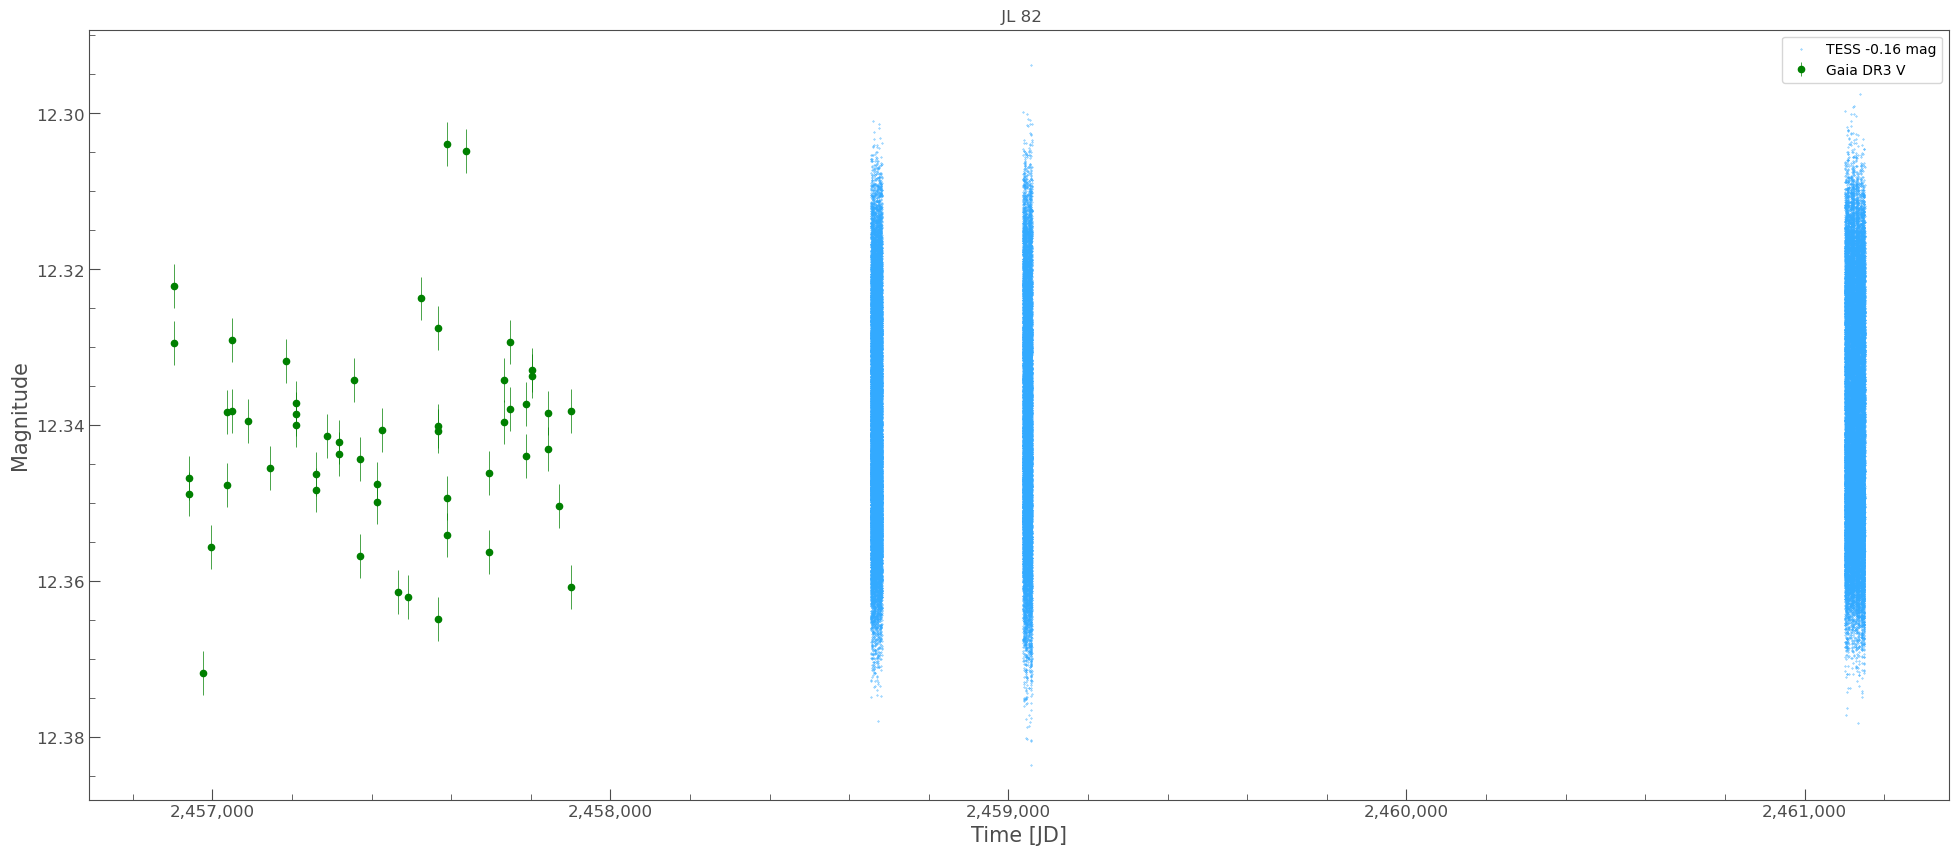

In [71]:
# reload(lkem)
# Not needed
# plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name, plot_options=plot_options);
# ax.set_title(ax.get_title() + "");

#### Phase Plot


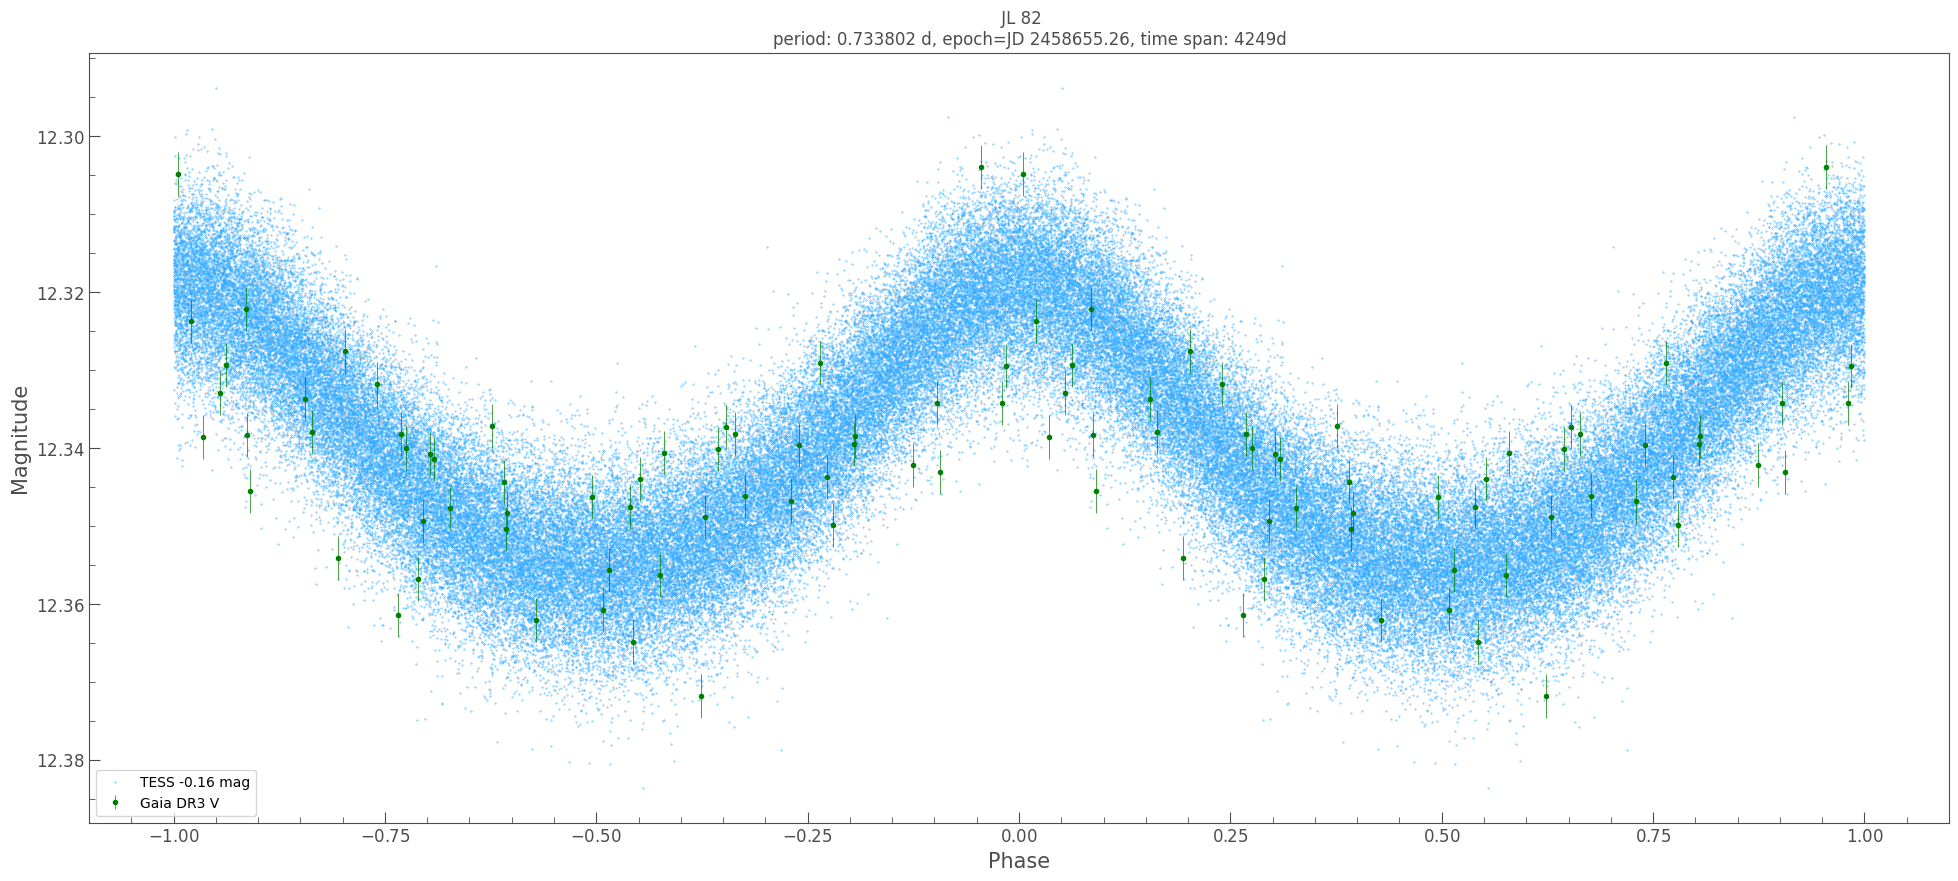

In [9]:
# reload(lkem)

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    epoch_value_str=f"JD {epoch_time_hjd_final}",  # for plotting output only to shwo the trialing 0 kept in the Decimal object
    plot_options=plot_options,
);
ax.legend(loc="lower left");
# ylim = (None, None)  # hide the outliers 
# ax.set_ylim(*ylim);
# ax.set_title(ax.get_title());  # + ", outliers truncated")


In [ ]:
# # zoom plot Min I
# # - make TESS more visible:  larger dots
# plot_options_zoom = plot_options


# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     # duration_hr=duration_hr_min_i_final  ,  # for plotting only
#     figsize=(24, 10),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# # ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_xlim(-0.1, 0.1);  # to see primary in details
# ylim = (None, None)
# ylim = (14.18, 14.07)
# ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     # duration_hr=duration_hr_min_ii_final ,  # for plotting only
#     # duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(24, 10),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# # ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final - 0.1, epoch_phase_min_ii_final + 0.1);  # to see secondary in details
# ylim = (14.16, 14.07)
# ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


### Pulsation Phase Plot

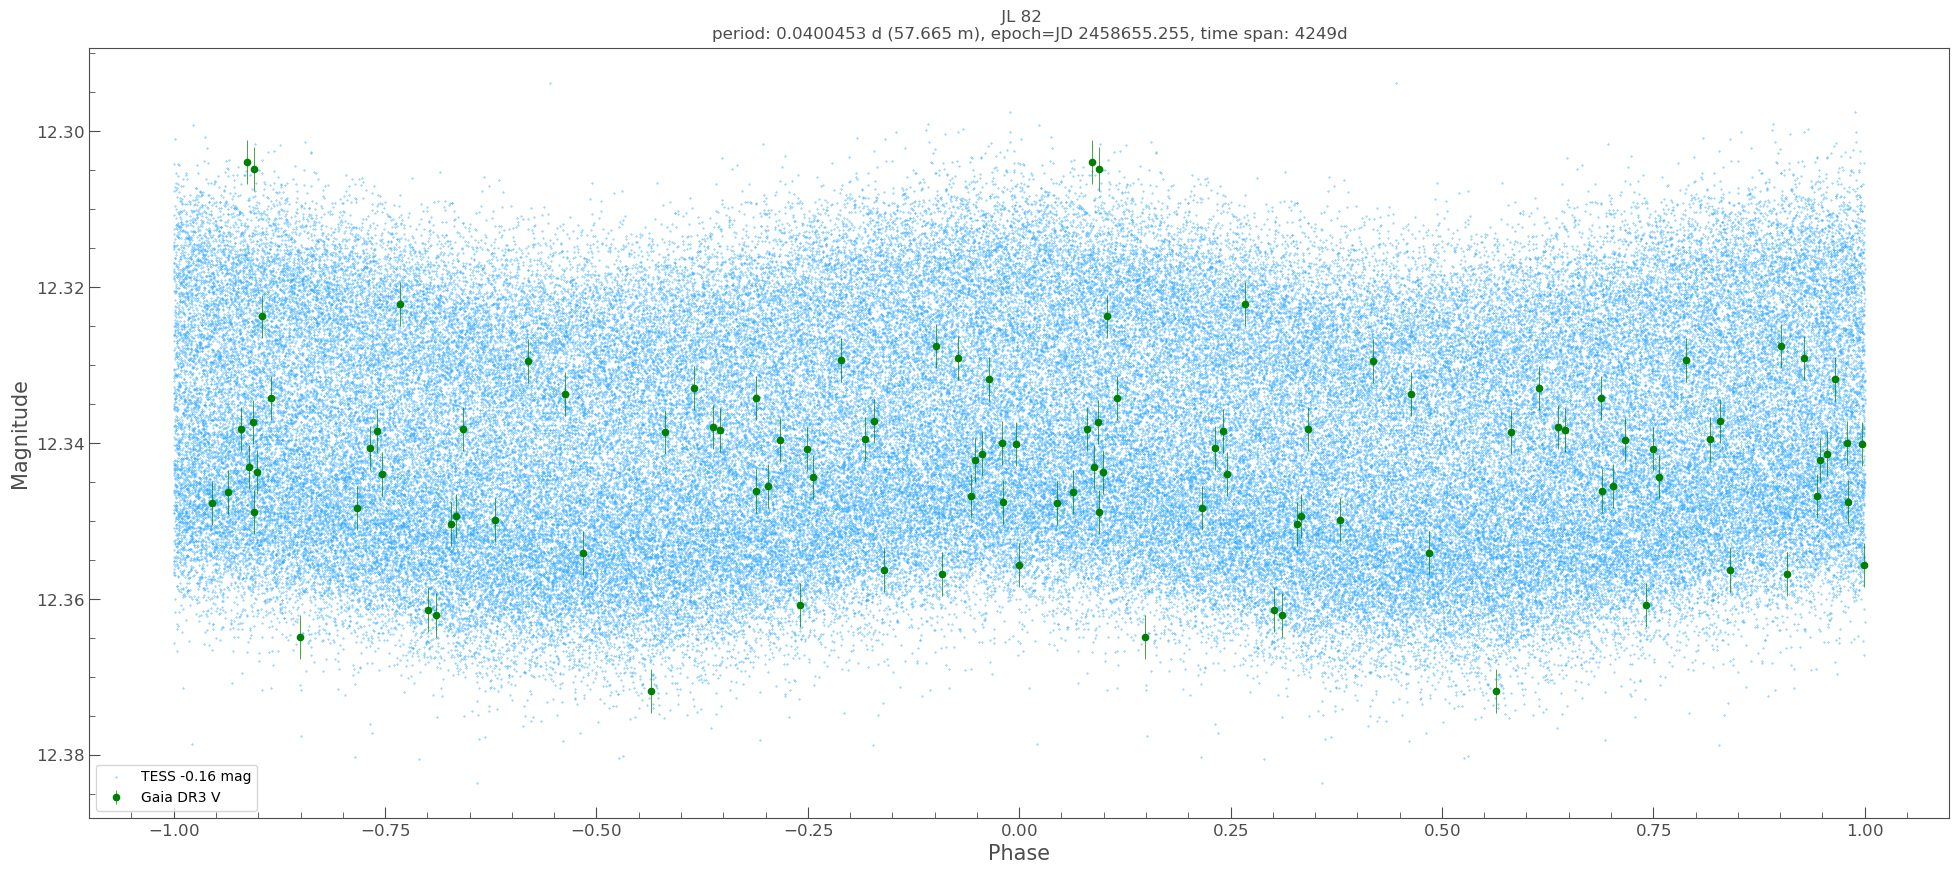

In [96]:
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=puls_period_final,
    epoch=Time(puls_epoch_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");

### JD Plot (zoom for illustration)

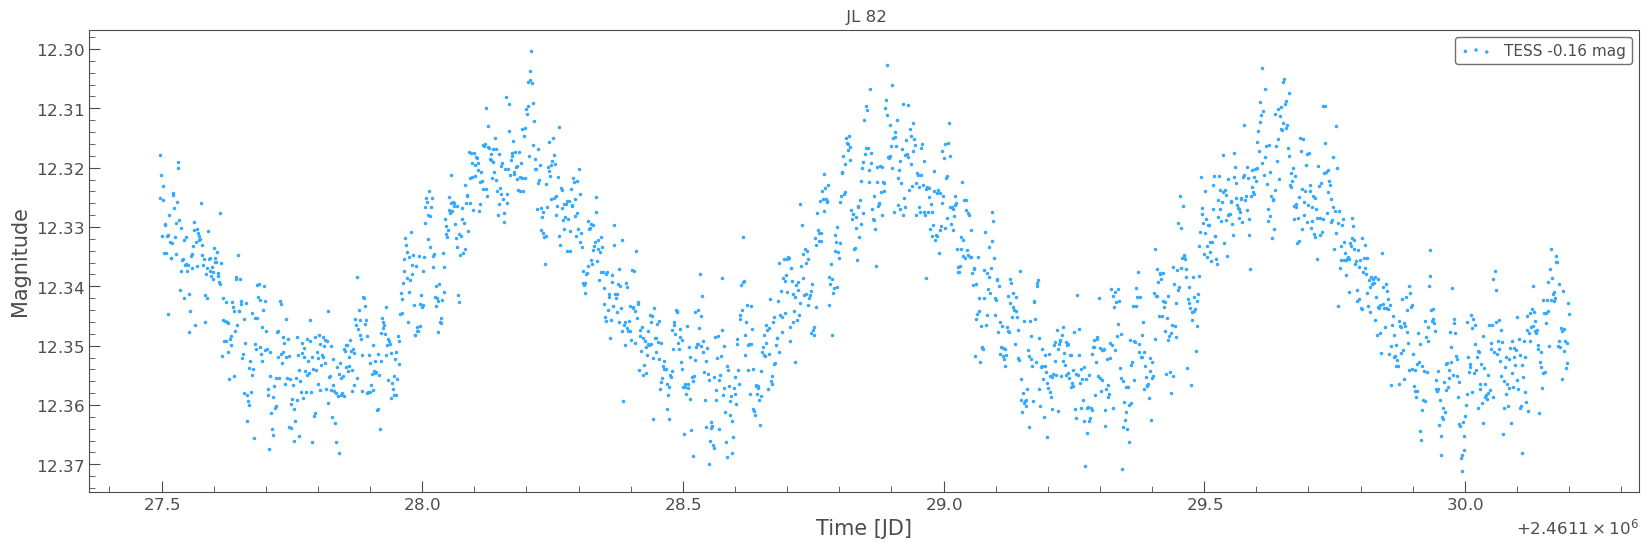

In [111]:
ax = tplt.scatter(lc_combined_dict["TESS"].truncate(2461127.2, 2461130.2), figsize=(20, 6), c="#3AF", s=9, label=lkem.get_label_of_source(lc_combined_dict, "TESS", mag_shift_precision=2));
ax.set_title(primary_name);

## VSX Report Table

In [30]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df


def vsx_phase(phase):
    # the phase I used above is from [-0.5, +0.5]
    # convert to the phase [0, 1[ used by VSX
    if phase < -0.5 or phase > 0.5:
        raise ValueError(f"Input phase needs to be in [-0.5, 0.5] range. Actual: {phase}")
    if phase >= 0:
        return phase 
    else: 
        return 1 + phase


In [10]:
import bibs_utils
# reload(bibs_utils)

                                                                                 
other_names = "Gaia DR3 6371205304939458944,TIC 352480413,TYC 9331-373-1,UCAC4 086-064009"  # in ExoFOP + SIMMBAD

remarks = (
    f"""Reflection effect elements given in the table. The pulsation periods are approximately 0.04 d - 0.2 d per 2009MNRAS.395..979K, with a dominant period of {puls_period_final} d from TESS data. SB per 2005A&A...442.1023E."""
)

revision_comment = "Type, pulsation periods from 2009MNRAS.395..979K. Orbital period, epoch from TESS and Gaia DR3 data. Range derived from Gaia DR3 data. Gaia DR3 position."

BIBS = bibs_utils.BIBS
vsx_report = dict(
    Position=f"{target_coord.ra.value:.6f}, {target_coord.dec.value:.6f}",  # VSX coordinate precision is between 5 - 6 digits in deg (2 digits in s of hms / RA, 1 digit in s / DEC)
    # Primary_Name=primary_name,  # no change
    Other_Names=other_names,
    Variable_Type="R+V1093HER",  #
    # Spectral_Type="",  # no change
    # Spectral_Type_Uncertain=False,
    Maximum_Magnitude=f"{max_flux_vmag}", 
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=f"{min_flux_vmag}",
    Minimum_Magnitude_band="V",  
    Minimum_Is_Amplitude=False,
    Period=f"{period_final}",  
    Epoch=f"{epoch_time_hjd_final}",
    # Rise_Duration_Pct=f"{100 * duration_hr_min_i_final / 24 / period_final:.0f}",  # N/A for EW type
    # Discoverer="",  
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.TESS_N,
    Reference0_Bib=BIBS.TESS_B,
    Reference1_Name=BIBS.GAIA_DR3_N,
    Reference1_Bib=BIBS.GAIA_DR3_B,
    Reference2_Name="Edelmann, H.; et al., 2005, High resolution spectroscopy of bright subdwarf B stars. I. Radial velocity variables",
    Reference2_Bib="2005A&A...442.1023E",
)


def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))


print("""
tic352480413_phase_plot_ref.png : Reflection Phase Plot - Reflection Effect Phase Plot from transformed Gaia DR3 V and TESS data, shifted to transformed Gaia DR3 V.
tic352480413_phase_plot_puls.png : Pulsation Phase Plot - Pulsation Phase Plot from transformed Gaia DR3 V and TESS data, shifted to transformed Gaia DR3 V.
tic352480413_jd_plot_zoom_tess.png : TESS Lightcurve (zoom) - A 3-day window of TESS lightcurve for illustration.
""")


Other Names (1 line each):
Gaia DR3 6371205304939458944
TIC 352480413
TYC 9331-373-1
UCAC4 086-064009

Reflection effect elements given in the table. The pulsation periods are approximately 0.04 d - 0.2 d per 2009MNRAS.395..979K, with a dominant period of 0.0400453 d from TESS data. SB per 2005A&A...442.1023E.

Type, pulsation periods from 2009MNRAS.395..979K. Orbital period, epoch from TESS and Gaia DR3 data. Range derived from Gaia DR3 data. Gaia DR3 position.


,Field,Value
0,Position,"324.005399, -72.807562"
1,Other_Names,"Gaia DR3 6371205304939458944,TIC 352480413,TYC 9331-373-1,UCAC4 086-064009"
2,Variable_Type,R+V1093HER
3,Maximum_Magnitude,12.32
4,Maximum_Magnitude_band,V
5,Minimum_Magnitude,12.36
6,Minimum_Magnitude_band,V
7,Minimum_Is_Amplitude,False
8,Period,0.733802
9,Epoch,2458655.26



tic352480413_phase_plot_ref.png : Reflection Phase Plot - Reflection Effect Phase Plot from transformed Gaia DR3 V and TESS data, shifted to transformed Gaia DR3 V.
tic352480413_phase_plot_puls.png : Pulsation Phase Plot - Pulsation Phase Plot from transformed Gaia DR3 V and TESS data, shifted to transformed Gaia DR3 V.
tic352480413_jd_plot_zoom_tess.png : TESS Lightcurve (zoom) - A 3-day window of TESS lightcurve for illustration.

